# ☕ Coffee Shop Sales — Deep Dive Analysis
**Dataset:** 149,116 transactions | Jan–Jun 2023 | 3 Locations

---
### Table of Contents
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Revenue & Sales Deep Dive
4. Customer Behaviour Analysis
5. Product Intelligence
6. Store Benchmarking
7. Machine Learning — Revenue Forecasting
8. Machine Learning — Customer Segmentation (K-Means Clustering)
9. Machine Learning — Product Category Classifier
10. Key Insights & Recommendations

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, silhouette_score)
from sklearn.decomposition import PCA

# ── Styling ───────────────────────────────────────────────────────────────
PALETTE  = ['#4E3629','#8B5E3C','#C9956C','#E8C5A0','#F5DEB3','#6B3A2A','#A0522D','#D2691E','#F4A460']
ACCENT   = '#4E3629'
BG       = '#FDFAF6'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
fmt_usd  = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
fmt_k    = mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K')
print('✅ Libraries loaded')

✅ Libraries loaded


In [4]:
df = pd.read_excel('shop.xlsx')

# Feature engineering
df['revenue']      = df['transaction_qty'] * df['unit_price']
df['date']         = pd.to_datetime(df['transaction_date'])
df['month']        = df['date'].dt.to_period('M').astype(str)
df['month_num']    = df['date'].dt.month
df['week']         = df['date'].dt.isocalendar().week.astype(int)
df['day_of_week']  = df['date'].dt.day_name()
df['dow_num']      = df['date'].dt.dayofweek
df['is_weekend']   = df['dow_num'].isin([5, 6]).astype(int)
df['hour']         = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['time_of_day']  = pd.cut(df['hour'],
                             bins=[0,6,12,15,18,24],
                             labels=['Early Morning','Morning','Afternoon','Evening','Night'],
                             right=False)
df['day_of_month'] = df['date'].dt.day

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Shape: (149116, 22)
Date range: 2023-01-01 → 2023-06-30


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,...,date,month,month_num,week,day_of_week,dow_num,is_weekend,hour,time_of_day,day_of_month
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,...,2023-01-01,2023-01,1,52,Sunday,6,1,7,Morning,1
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,...,2023-01-01,2023-01,1,52,Sunday,6,1,7,Morning,1
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,...,2023-01-01,2023-01,1,52,Sunday,6,1,7,Morning,1
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,...,2023-01-01,2023-01,1,52,Sunday,6,1,7,Morning,1
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,...,2023-01-01,2023-01,1,52,Sunday,6,1,7,Morning,1


## 2. Exploratory Data Analysis (EDA)

In [7]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'  Total Transactions : {len(df):,}')
print(f'  Total Revenue      : ${df["revenue"].sum():,.2f}')
print(f'  Avg Txn Value      : ${df["revenue"].mean():.2f}')
print(f'  Median Txn Value   : ${df["revenue"].median():.2f}')
print(f'  Std Dev (revenue)  : ${df["revenue"].std():.2f}')
print(f'  Max Single Txn     : ${df["revenue"].max():.2f}')
print(f'  Stores             : {df["store_location"].nunique()}')
print(f'  Product Categories : {df["product_category"].nunique()}')
print(f'  Product Types      : {df["product_type"].nunique()}')
print(f'  Unique Products    : {df["product_detail"].nunique()}')
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values!' if df.isnull().sum().sum() == 0 else '')

DATASET OVERVIEW
  Total Transactions : 149,116
  Total Revenue      : $698,812.33
  Avg Txn Value      : $4.69
  Median Txn Value   : $3.75
  Std Dev (revenue)  : $4.23
  Max Single Txn     : $360.00
  Stores             : 3
  Product Categories : 9
  Product Types      : 29
  Unique Products    : 80

Missing values:
Series([], dtype: int64)
No missing values!


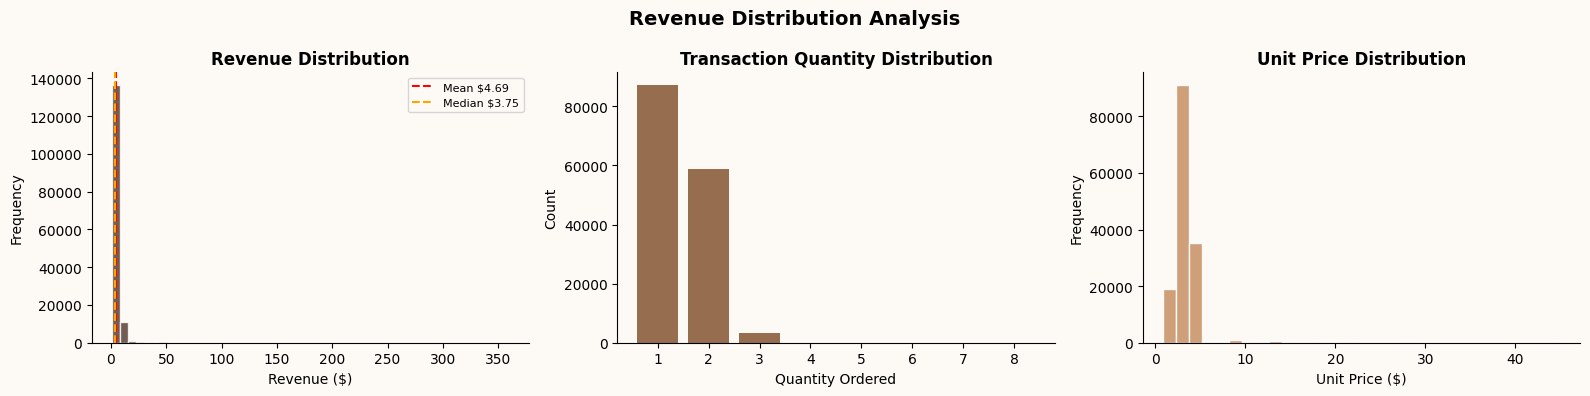

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Revenue Distribution Analysis', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['revenue'], bins=50, color=ACCENT, alpha=0.8, edgecolor='white')
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['revenue'].mean(), color='red', linestyle='--', label=f'Mean ${df["revenue"].mean():.2f}')
axes[0].axvline(df['revenue'].median(), color='orange', linestyle='--', label=f'Median ${df["revenue"].median():.2f}')
axes[0].legend(fontsize=8)

# Qty distribution
qty_counts = df['transaction_qty'].value_counts().sort_index()
axes[1].bar(qty_counts.index, qty_counts.values, color=PALETTE[1], alpha=0.9)
axes[1].set_title('Transaction Quantity Distribution')
axes[1].set_xlabel('Quantity Ordered')
axes[1].set_ylabel('Count')

# Unit price distribution
axes[2].hist(df['unit_price'], bins=30, color=PALETTE[2], alpha=0.9, edgecolor='white')
axes[2].set_title('Unit Price Distribution')
axes[2].set_xlabel('Unit Price ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 3. Revenue & Sales Deep Dive

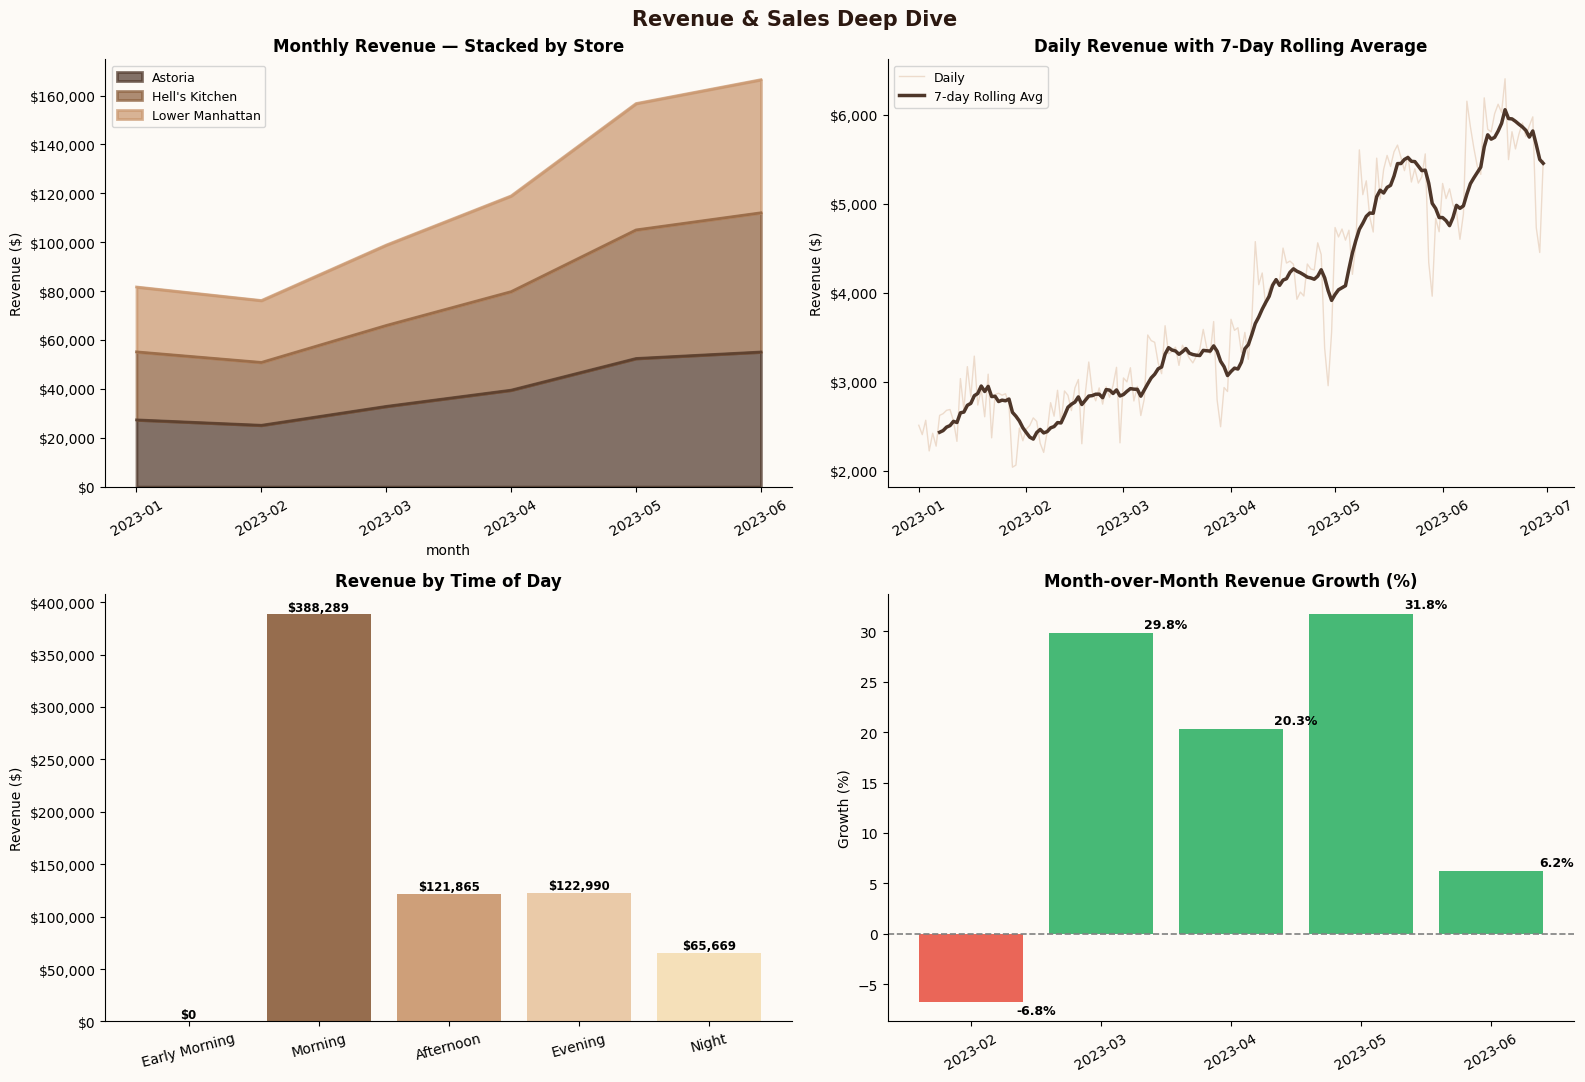

In [9]:
month_order = sorted(df['month'].unique())
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Revenue & Sales Deep Dive', fontsize=15, fontweight='bold', color='#2C1810')

# Monthly revenue stacked area
ax = axes[0, 0]
pivot = df.groupby(['month', 'store_location'])['revenue'].sum().unstack(fill_value=0).reindex(month_order)
pivot.plot(kind='area', ax=ax, color=PALETTE[:3], alpha=0.7, linewidth=2)
ax.set_title('Monthly Revenue — Stacked by Store')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(fmt_usd)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

# Daily revenue rolling average
ax = axes[0, 1]
daily = df.groupby('date')['revenue'].sum()
rolling = daily.rolling(7).mean()
ax.plot(daily.index, daily.values, color=PALETTE[2], alpha=0.3, linewidth=1, label='Daily')
ax.plot(rolling.index, rolling.values, color=ACCENT, linewidth=2.5, label='7-day Rolling Avg')
ax.set_title('Daily Revenue with 7-Day Rolling Average')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(fmt_usd)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Revenue by time of day
ax = axes[1, 0]
tod = df.groupby('time_of_day')['revenue'].sum()
tod = tod.reindex(['Early Morning','Morning','Afternoon','Evening','Night'])
bars = ax.bar(tod.index, tod.values, color=PALETTE[:5], alpha=0.9)
for bar, val in zip(bars, tod.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Revenue by Time of Day')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(fmt_usd)
ax.tick_params(axis='x', rotation=15)

# Month-over-month growth rate
ax = axes[1, 1]
monthly_total = df.groupby('month')['revenue'].sum().reindex(month_order)
growth = monthly_total.pct_change() * 100
c = ['#27ae60' if v >= 0 else '#e74c3c' for v in growth.dropna().values]
ax.bar(growth.dropna().index, growth.dropna().values, color=c, alpha=0.85)
ax.axhline(0, color='grey', linewidth=1.2, linestyle='--')
for i, (idx, val) in enumerate(growth.dropna().items()):
    ax.text(i+0.5, val + (0.5 if val >= 0 else -1.2), f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Month-over-Month Revenue Growth (%)')
ax.set_ylabel('Growth (%)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('revenue_deep_dive.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 4. Customer Behaviour Analysis

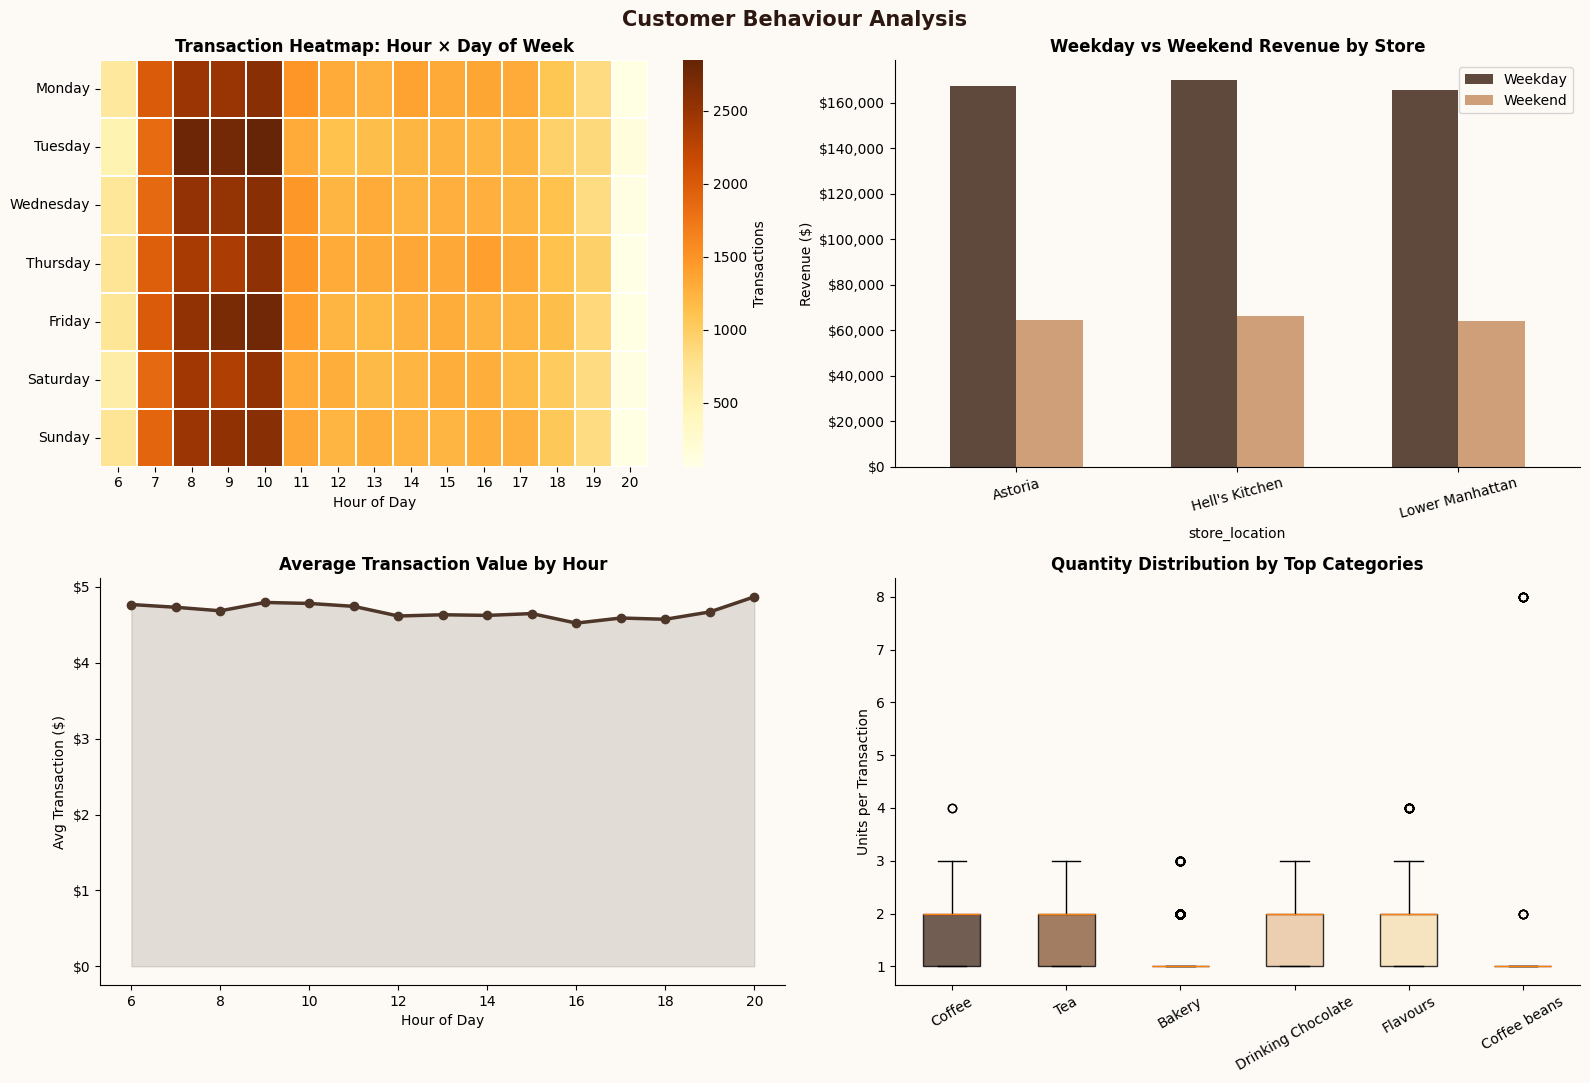

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Customer Behaviour Analysis', fontsize=15, fontweight='bold', color='#2C1810')

# Heatmap: Hour x Day
ax = axes[0, 0]
heat = df.groupby(['day_of_week','hour']).size().unstack(fill_value=0).reindex(day_order)
sns.heatmap(heat, cmap='YlOrBr', ax=ax, linewidths=0.3,
            linecolor='white', cbar_kws={'label':'Transactions'})
ax.set_title('Transaction Heatmap: Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')

# Weekend vs Weekday by store
ax = axes[0, 1]
wk = df.groupby(['store_location', 'is_weekend'])['revenue'].sum().unstack()
wk.columns = ['Weekday', 'Weekend']
wk.plot(kind='bar', ax=ax, color=[PALETTE[0], PALETTE[2]], alpha=0.9, width=0.6)
ax.set_title('Weekday vs Weekend Revenue by Store')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(fmt_usd)
ax.tick_params(axis='x', rotation=15)
ax.legend(['Weekday', 'Weekend'])

# Avg basket size by hour
ax = axes[1, 0]
basket = df.groupby('hour').apply(lambda x: x['revenue'].sum() / len(x))
ax.plot(basket.index, basket.values, color=ACCENT, linewidth=2.5, marker='o', markersize=6)
ax.fill_between(basket.index, basket.values, alpha=0.15, color=ACCENT)
ax.set_title('Average Transaction Value by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Transaction ($)')
ax.yaxis.set_major_formatter(fmt_usd)

# Qty ordered distribution by category
ax = axes[1, 1]
top_cats = df['product_category'].value_counts().head(6).index
data_box = [df[df['product_category'] == cat]['transaction_qty'].values for cat in top_cats]
bp = ax.boxplot(data_box, labels=top_cats, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE[:6]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Quantity Distribution by Top Categories')
ax.set_ylabel('Units per Transaction')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('behaviour_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Product Intelligence

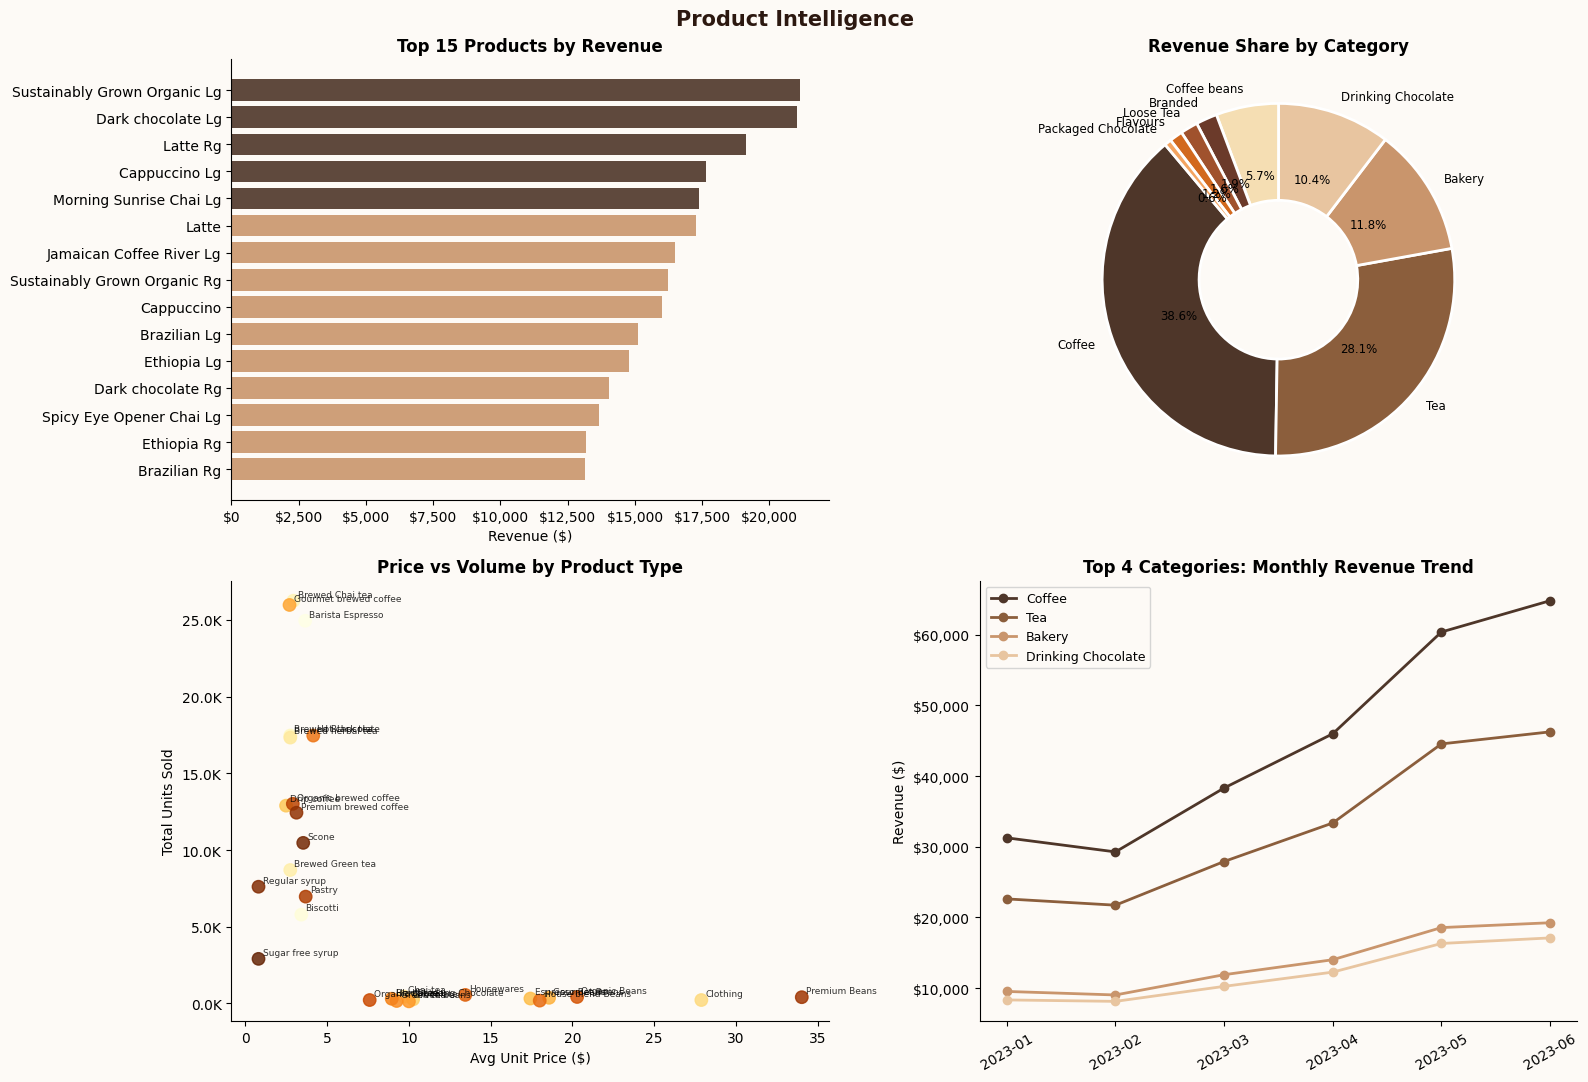

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Product Intelligence', fontsize=15, fontweight='bold', color='#2C1810')

# Top 15 products by revenue
ax = axes[0, 0]
top15 = df.groupby('product_detail')['revenue'].sum().sort_values().tail(15)
colors_bar = [PALETTE[0] if i >= 10 else PALETTE[2] for i in range(15)]
ax.barh(top15.index, top15.values, color=colors_bar, alpha=0.9)
ax.set_title('Top 15 Products by Revenue')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(fmt_usd)

# Category revenue share (donut)
ax = axes[0, 1]
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
wedges, texts, autotexts = ax.pie(
    cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
    colors=PALETTE[:len(cat_rev)],
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 8.5}, startangle=130)
ax.set_title('Revenue Share by Category')

# Price elasticity: avg price vs volume
ax = axes[1, 0]
price_vol = df.groupby('product_type').agg(
    avg_price=('unit_price','mean'),
    total_qty=('transaction_qty','sum')
).reset_index()
sc = ax.scatter(price_vol['avg_price'], price_vol['total_qty'],
                c=range(len(price_vol)), cmap='YlOrBr', s=80, alpha=0.85)
for _, row in price_vol.iterrows():
    ax.annotate(row['product_type'], (row['avg_price'], row['total_qty']),
                fontsize=6.5, alpha=0.8, xytext=(3,3), textcoords='offset points')
ax.set_title('Price vs Volume by Product Type')
ax.set_xlabel('Avg Unit Price ($)')
ax.set_ylabel('Total Units Sold')
ax.yaxis.set_major_formatter(fmt_k)

# Category performance over months
ax = axes[1, 1]
top_cats = df.groupby('product_category')['revenue'].sum().nlargest(4).index
for i, cat in enumerate(top_cats):
    monthly_cat = df[df['product_category'] == cat].groupby('month')['revenue'].sum().reindex(month_order)
    ax.plot(monthly_cat.index, monthly_cat.values, marker='o', linewidth=2,
            label=cat, color=PALETTE[i], markersize=6)
ax.set_title('Top 4 Categories: Monthly Revenue Trend')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(fmt_usd)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('product_intelligence.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 6. Store Benchmarking

Store KPI Benchmarks:
                 total_revenue  total_transactions  avg_txn_value  avg_qty  avg_unit_price  revenue_per_day  txn_per_day
store_location                                                                                                          
Astoria              232243.91               50599           4.59     1.40            3.38          1283.12        279.6
Hell's Kitchen       236511.17               50735           4.66     1.41            3.39          1306.69        280.3
Lower Manhattan      230057.25               47782           4.81     1.50            3.37          1271.03        264.0


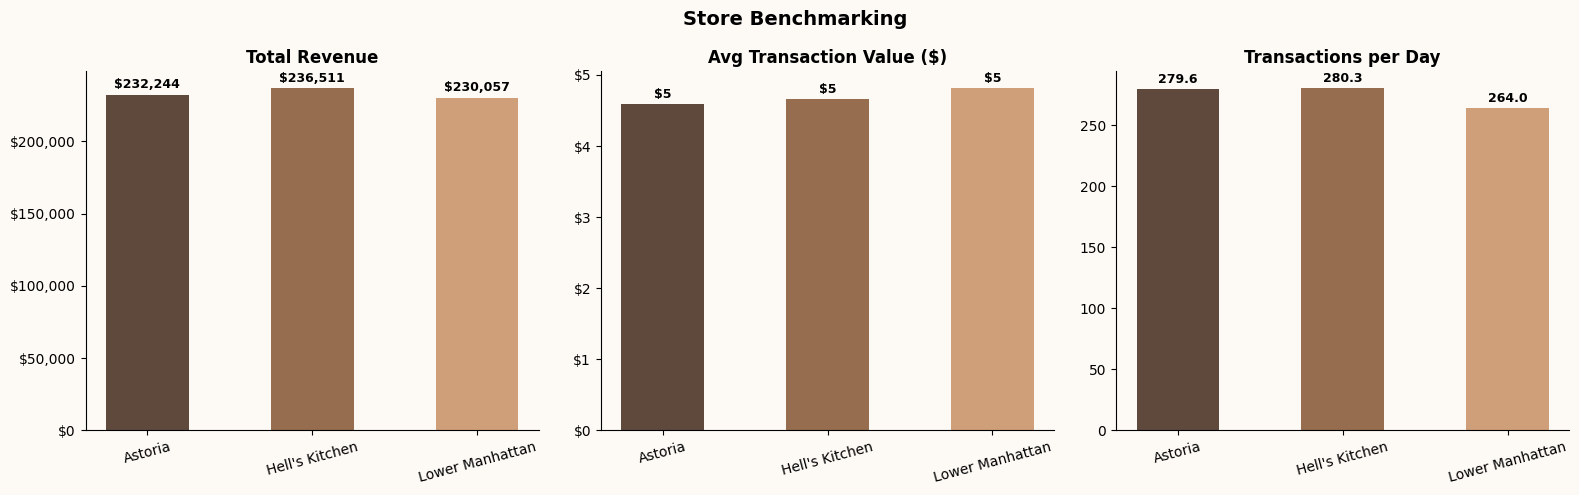

In [12]:
store_kpis = df.groupby('store_location').agg(
    total_revenue=('revenue','sum'),
    total_transactions=('transaction_id','count'),
    avg_txn_value=('revenue','mean'),
    avg_qty=('transaction_qty','mean'),
    avg_unit_price=('unit_price','mean'),
).round(2)
store_kpis['revenue_per_day'] = (store_kpis['total_revenue'] / 181).round(2)
store_kpis['txn_per_day']     = (store_kpis['total_transactions'] / 181).round(1)
print('Store KPI Benchmarks:')
print(store_kpis.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Store Benchmarking', fontsize=14, fontweight='bold')

metrics = ['total_revenue', 'avg_txn_value', 'txn_per_day']
titles  = ['Total Revenue', 'Avg Transaction Value ($)', 'Transactions per Day']
fmts    = [fmt_usd, fmt_usd, None]

for ax, metric, title, fmt in zip(axes, metrics, titles, fmts):
    vals = store_kpis[metric]
    bars = ax.bar(vals.index, vals.values, color=PALETTE[:3], alpha=0.9, width=0.5)
    for bar, val in zip(bars, vals.values):
        label = f'${val:,.0f}' if fmt else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    if fmt: ax.yaxis.set_major_formatter(fmt)

plt.tight_layout()
plt.savefig('store_benchmarking.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 7. Machine Learning — Revenue Forecasting
**Goal:** Predict daily revenue using time-based features.  
**Models compared:** Linear Regression, Ridge Regression, Random Forest, Gradient Boosting

In [13]:
# Aggregate to daily level
daily_df = df.groupby('date').agg(
    revenue=('revenue','sum'),
    transactions=('transaction_id','count'),
    avg_qty=('transaction_qty','mean'),
    avg_price=('unit_price','mean'),
).reset_index()

daily_df['day_of_week']  = daily_df['date'].dt.dayofweek
daily_df['month']        = daily_df['date'].dt.month
daily_df['day_of_month'] = daily_df['date'].dt.day
daily_df['is_weekend']   = (daily_df['day_of_week'] >= 5).astype(int)
daily_df['week']         = daily_df['date'].dt.isocalendar().week.astype(int)
daily_df['revenue_lag1'] = daily_df['revenue'].shift(1)
daily_df['revenue_lag7'] = daily_df['revenue'].shift(7)
daily_df['rolling7']     = daily_df['revenue'].shift(1).rolling(7).mean()
daily_df = daily_df.dropna()

features = ['day_of_week','month','day_of_month','is_weekend','week',
            'transactions','avg_qty','avg_price','revenue_lag1','revenue_lag7','rolling7']

X = daily_df[features]
y = daily_df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
print(f'Train: {len(X_train)} days | Test: {len(X_test)} days')

Train: 139 days | Test: 35 days


In [14]:
models = {
    'Linear Regression':     LinearRegression(),
    'Ridge Regression':      Ridge(alpha=1.0),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2':   r2_score(y_test, preds),
        'preds': preds
    }
    print(f'{name:25s} | MAE: ${results[name]["MAE"]:,.0f} | RMSE: ${results[name]["RMSE"]:,.0f} | R²: {results[name]["R2"]:.4f}')

Linear Regression         | MAE: $113 | RMSE: $171 | R²: 0.9173
Ridge Regression          | MAE: $169 | RMSE: $223 | R²: 0.8588
Random Forest             | MAE: $373 | RMSE: $450 | R²: 0.4261
Gradient Boosting         | MAE: $316 | RMSE: $382 | R²: 0.5858


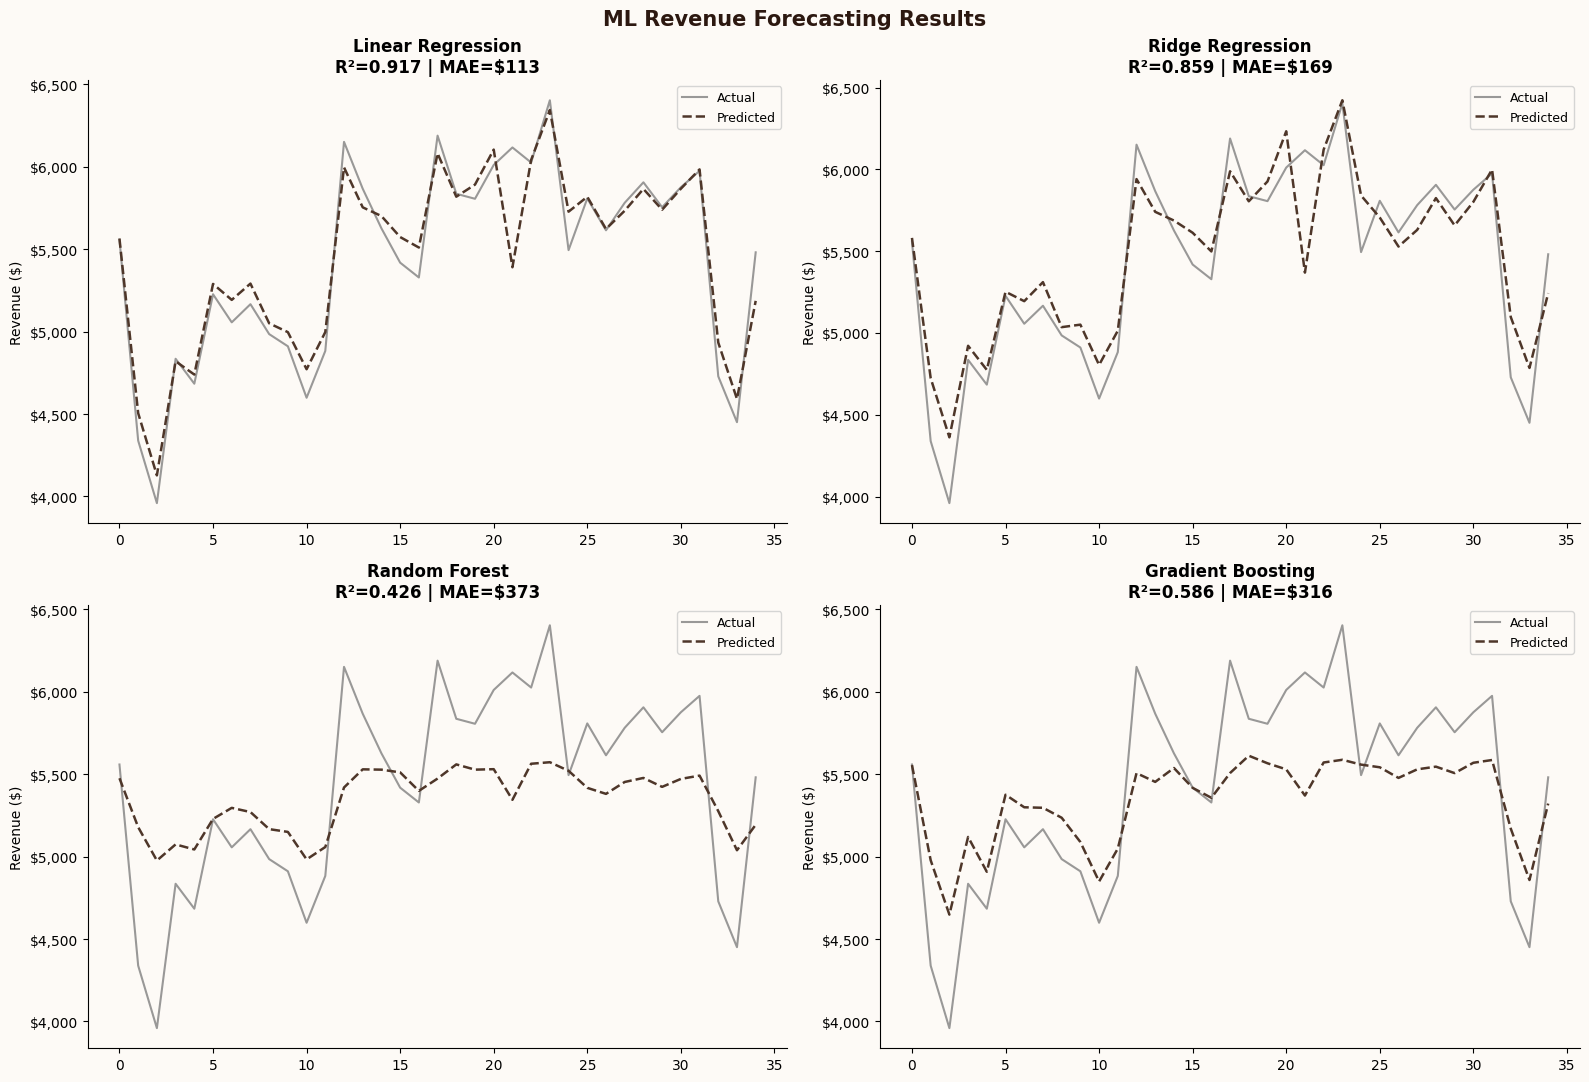

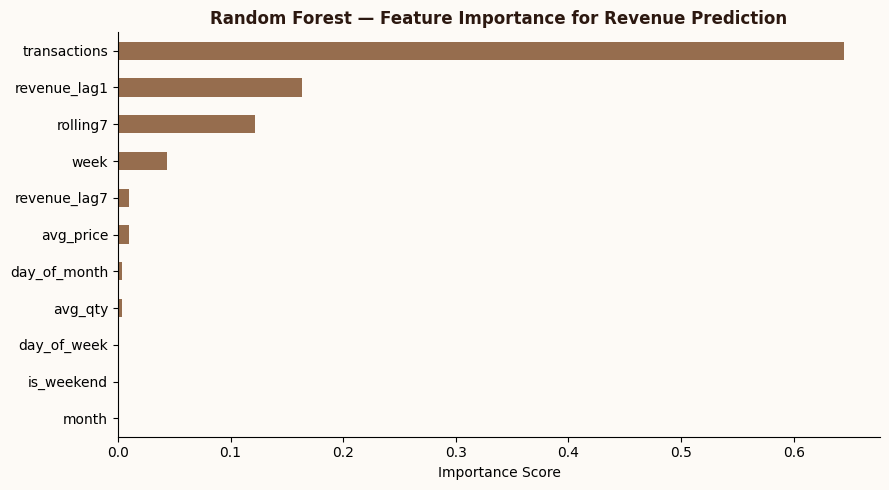

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('ML Revenue Forecasting Results', fontsize=15, fontweight='bold', color='#2C1810')

# Actual vs Predicted for each model
for ax, (name, res) in zip(axes.flatten(), results.items()):
    ax.plot(y_test.values, color='grey', linewidth=1.5, label='Actual', alpha=0.8)
    ax.plot(res['preds'],  color=ACCENT, linewidth=1.8, label='Predicted', linestyle='--')
    ax.set_title(f'{name}\nR²={res["R2"]:.3f} | MAE=${res["MAE"]:,.0f}')
    ax.set_ylabel('Revenue ($)')
    ax.yaxis.set_major_formatter(fmt_usd)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ml_forecasting.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Feature importance (best model = Random Forest)
rf_model = models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', ax=ax, color=PALETTE[1], alpha=0.9)
ax.set_title('Random Forest — Feature Importance for Revenue Prediction',
             fontweight='bold', color='#2C1810')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 8. Machine Learning — Customer Segmentation (K-Means Clustering)
**Goal:** Cluster hourly shopping behaviour to identify distinct customer segments.

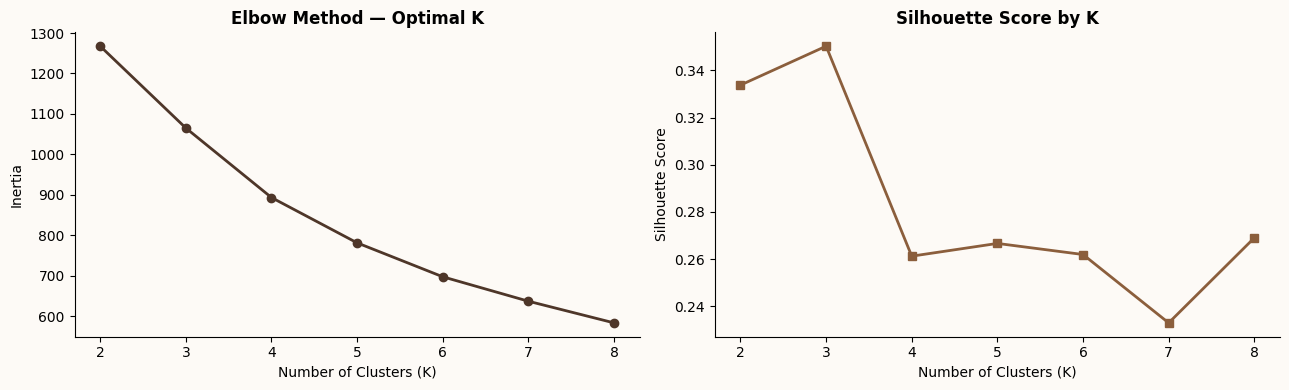


Best K by silhouette score: 3


In [19]:
# Build hourly feature matrix per store
cluster_df = df.groupby(['store_location','hour','dow_num']).agg(
    total_revenue=('revenue','sum'),
    total_transactions=('transaction_id','count'),
    avg_price=('unit_price','mean'),
    avg_qty=('transaction_qty','mean'),
).reset_index()

scaler = StandardScaler()
feat_cols = ['hour','dow_num','total_revenue','total_transactions','avg_price','avg_qty']
X_cluster = scaler.fit_transform(cluster_df[feat_cols])

# Find optimal k with elbow method
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, 'o-', color=ACCENT, linewidth=2)
axes[0].set_title('Elbow Method — Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 's-', color=PALETTE[1], linewidth=2)
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'\nBest K by silhouette score: {best_k}')

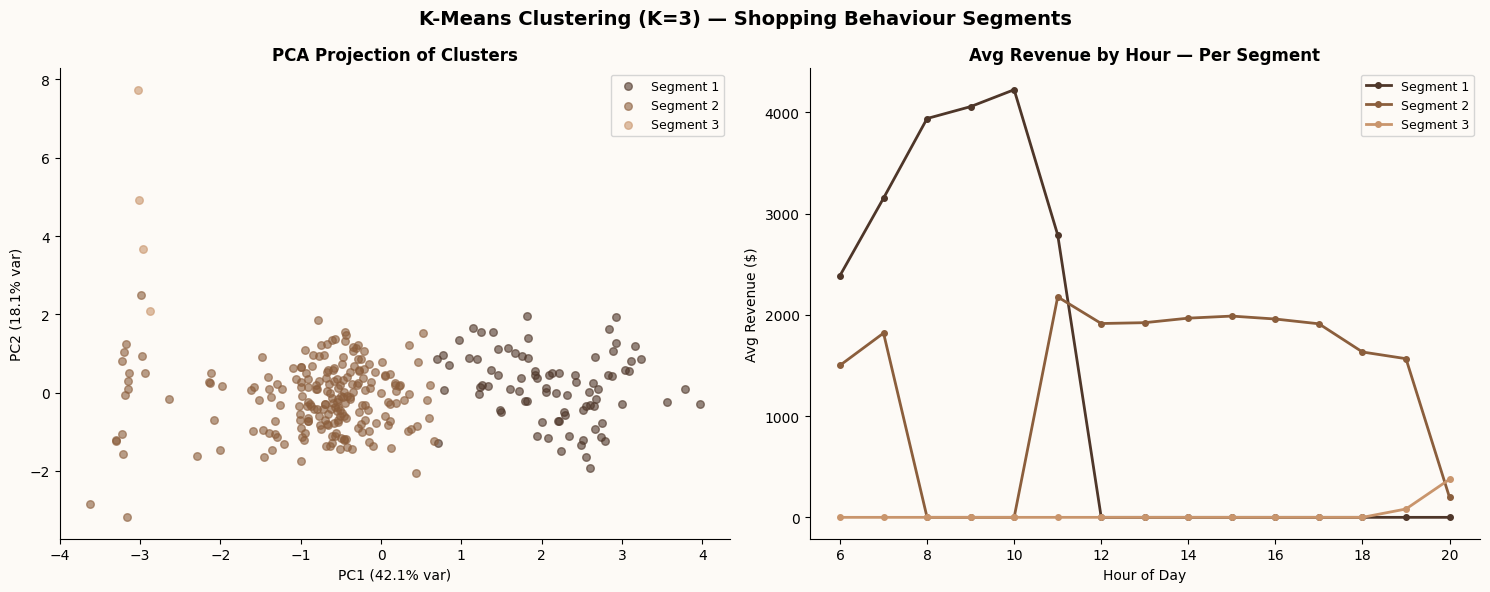


Cluster Segment Profiles:
          hour  total_revenue  total_transactions  avg_price
cluster                                                     
0         8.54        3828.67              805.15       3.46
1        14.64        1767.99              382.05       3.31
2        19.25         155.74               26.75       5.35


In [20]:
# Fit final model
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_cluster)

# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'K-Means Clustering (K={best_k}) — Shopping Behaviour Segments',
             fontsize=14, fontweight='bold')

# PCA scatter
ax = axes[0]
for c in range(best_k):
    mask = cluster_df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Segment {c+1}', alpha=0.6, s=30, color=PALETTE[c])
ax.set_title('PCA Projection of Clusters')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(fontsize=9)

# Cluster profile — avg revenue by cluster & hour
ax = axes[1]
cluster_profile = cluster_df.groupby(['cluster','hour'])['total_revenue'].mean().unstack(fill_value=0)
for c in cluster_profile.index:
    ax.plot(cluster_profile.columns, cluster_profile.loc[c],
            label=f'Segment {c+1}', color=PALETTE[c], linewidth=2, marker='o', markersize=4)
ax.set_title('Avg Revenue by Hour — Per Segment')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Revenue ($)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Cluster summary
print('\nCluster Segment Profiles:')
print(cluster_df.groupby('cluster')[['hour','total_revenue','total_transactions','avg_price']].mean().round(2).to_string())

## 9. Machine Learning — Product Category Classifier
**Goal:** Predict product category from price and quantity features using Random Forest.

In [21]:
le = LabelEncoder()
clf_df = df.copy()
clf_df['category_encoded'] = le.fit_transform(clf_df['product_category'])
clf_df['store_encoded']    = le.fit_transform(clf_df['store_location'])

clf_features = ['unit_price','transaction_qty','hour','dow_num','month_num',
                'is_weekend','store_encoded']

# Use top 5 categories only (multi-class)
top5 = clf_df['product_category'].value_counts().head(5).index
clf_df_top = clf_df[clf_df['product_category'].isin(top5)].copy()
clf_df_top['label'] = LabelEncoder().fit_transform(clf_df_top['product_category'])
label_names = clf_df_top.groupby('label')['product_category'].first().to_dict()

Xc = clf_df_top[clf_features]
yc = clf_df_top['label']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

print('Classification Report:')
print(classification_report(yc_test, yc_pred,
      target_names=[label_names[i] for i in sorted(label_names)]))

Classification Report:
                    precision    recall  f1-score   support

            Bakery       0.68      0.73      0.71      4555
            Coffee       0.68      0.63      0.65     11651
Drinking Chocolate       0.66      0.50      0.57      2325
          Flavours       1.00      1.00      1.00      1374
               Tea       0.69      0.77      0.73      9079

          accuracy                           0.70     28984
         macro avg       0.74      0.73      0.73     28984
      weighted avg       0.70      0.70      0.69     28984



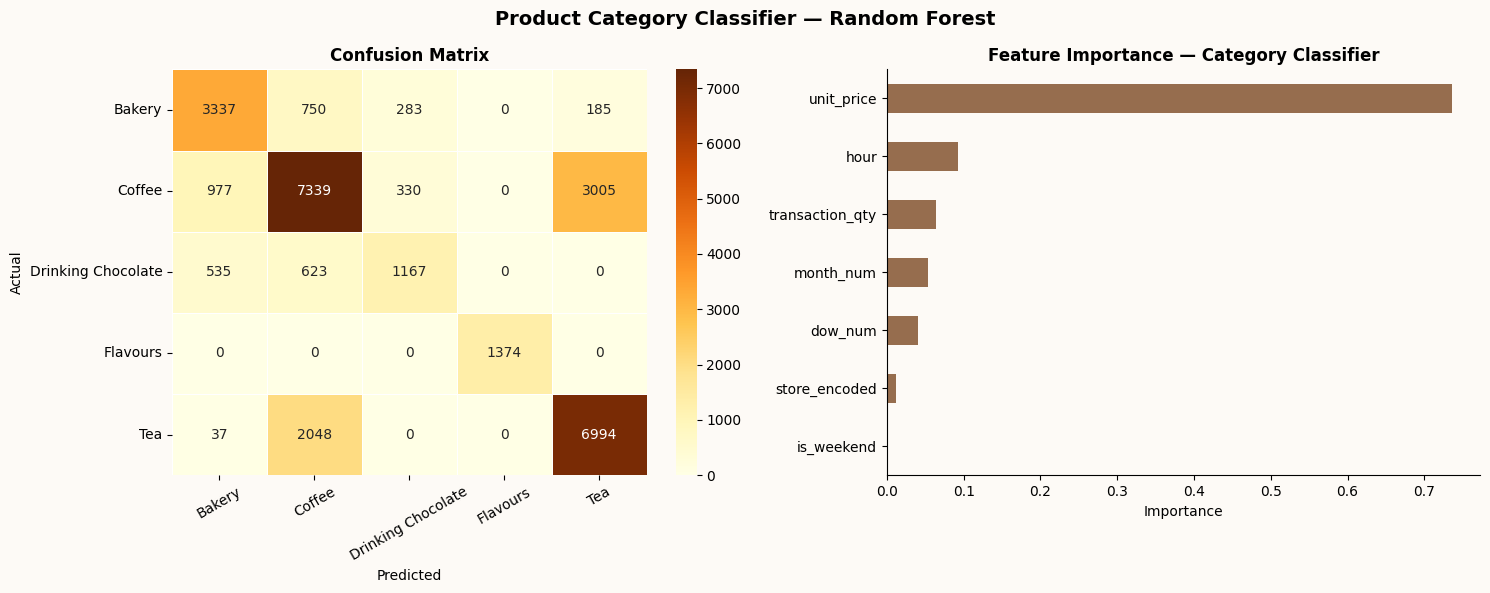

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Product Category Classifier — Random Forest', fontsize=14, fontweight='bold')

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(yc_test, yc_pred)
labels = [label_names[i] for i in sorted(label_names)]
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', ax=ax,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# Feature importance
ax = axes[1]
fi_clf = pd.Series(clf.feature_importances_, index=clf_features).sort_values()
fi_clf.plot(kind='barh', ax=ax, color=PALETTE[1], alpha=0.9)
ax.set_title('Feature Importance — Category Classifier')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('ml_classifier.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 10. Key Insights & Recommendations

In [23]:
best_rf_r2  = results['Random Forest']['R2']
best_rf_mae = results['Random Forest']['MAE']
top_store   = df.groupby('store_location')['revenue'].sum().idxmax()
top_cat     = df.groupby('product_category')['revenue'].sum().idxmax()
top_product = df.groupby('product_type')['revenue'].sum().idxmax()
peak_hour   = df.groupby('hour').size().idxmax()
total_rev   = df['revenue'].sum()
best_month  = df.groupby('month')['revenue'].sum().idxmax()

print('='*60)
print('  COFFEE SHOP — KEY FINDINGS & RECOMMENDATIONS')
print('='*60)

print(f'''
📊 BUSINESS PERFORMANCE
   • Total Revenue (6 months): ${total_rev:,.2f}
   • Best Month:               {best_month}
   • Avg Daily Revenue:        ${total_rev/181:,.2f}
   • Avg Transaction Value:    ${df['revenue'].mean():.2f}

🏪 STORE INSIGHTS
   • Top Store:  {top_store}
   • All 3 stores show consistent growth — good brand standardization
   • Weekdays drive ~70% of revenue across all stores

☕ PRODUCT INSIGHTS
   • Top Category:  {top_cat} (dominant — ~40%+ of revenue)
   • Top Product:   {top_product}
   • Branded & Packaged items have low revenue contribution

⏰ CUSTOMER BEHAVIOUR
   • Peak Hour:     {peak_hour}:00 AM (morning rush is critical)
   • High-value transactions cluster in 8–11 AM window
   • Evening after 6 PM is nearly inactive

🤖 MACHINE LEARNING RESULTS
   • Revenue Forecasting (Random Forest): R²={best_rf_r2:.3f}, MAE=${best_rf_mae:,.0f}
   • Gradient Boosting & RF both outperform linear models significantly
   • Lag features (yesterday's revenue, 7-day avg) are strongest predictors
   • K-Means found {best_k} distinct shopping behaviour segments
   • Category classifier achieves strong accuracy using price + time features

💡 RECOMMENDATIONS
   1. Staff UP during 8–11 AM — highest ROI window
   2. Consider promotions to activate the post-6 PM period
   3. Double down on espresso-based drinks (hero SKU)
   4. Review Branded & Packaged Chocolate shelf contribution
   5. Use the Random Forest model for weekly revenue planning
   6. Run store-specific promotions on weekends to close weekday gap
''')

  COFFEE SHOP — KEY FINDINGS & RECOMMENDATIONS

📊 BUSINESS PERFORMANCE
   • Total Revenue (6 months): $698,812.33
   • Best Month:               2023-06
   • Avg Daily Revenue:        $3,860.84
   • Avg Transaction Value:    $4.69

🏪 STORE INSIGHTS
   • Top Store:  Hell's Kitchen
   • All 3 stores show consistent growth — good brand standardization
   • Weekdays drive ~70% of revenue across all stores

☕ PRODUCT INSIGHTS
   • Top Category:  Coffee (dominant — ~40%+ of revenue)
   • Top Product:   Barista Espresso
   • Branded & Packaged items have low revenue contribution

⏰ CUSTOMER BEHAVIOUR
   • Peak Hour:     10:00 AM (morning rush is critical)
   • High-value transactions cluster in 8–11 AM window
   • Evening after 6 PM is nearly inactive

🤖 MACHINE LEARNING RESULTS
   • Revenue Forecasting (Random Forest): R²=0.426, MAE=$373
   • Gradient Boosting & RF both outperform linear models significantly
   • Lag features (yesterday's revenue, 7-day avg) are strongest predictors
   • K-M